In [1]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))

In [2]:
import numpy as np

from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
abalone = fetch_ucirepo(id=1)

# data (as pandas dataframes) 
X = abalone.data.features 
y = abalone.data.targets 
X = X.drop(columns=['Sex'])

In [3]:
X = X.values.astype(float)
y = np.array(y).reshape(-1)

In [4]:
notebook1 = "real1_Abalone_1_10000"
notebook2 = "real1_Abalone_100_100"
notebook3 = "real1_Abalone_1000_10"
notebook4 = "real1_Abalone_100_100_long"
notebook5 = "real1_Abalone_20_500_long"

In [5]:
import pandas as pd
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from pathlib import Path
STORE_DIR = Path("store")
notebooks = [notebook1, notebook2, notebook3, notebook4, notebook5]

def load_method_payload(npz_path, method_key):
    data = np.load(npz_path, allow_pickle=True)
    payload = data[method_key]
    return payload.item() if hasattr(payload, "item") else payload

def get_y_test_subset(y, n_test_points, seed=42):
    _, X_test, _, y_test = train_test_split(X, y, random_state=42)
    rng = np.random.default_rng(seed)
    if n_test_points is not None and n_test_points < X_test.shape[0]:
        idx = rng.choice(X_test.shape[0], n_test_points, replace=False)
    else:
        idx = np.arange(X_test.shape[0])
    return y_test[idx]

In [6]:
def crps_from_samples(samples, y_true):
    n_points, n_samples = samples.shape
    term1 = np.mean(np.abs(samples - y_true[:, None]), axis=1)
    samples_sorted = np.sort(samples, axis=1)
    k = np.arange(1, n_samples + 1)
    coeffs = (2 * k - n_samples - 1)[None, :]
    term2 = np.sum(coeffs * samples_sorted, axis=1) / (n_samples ** 2)
    return term1 - term2

def compute_metrics_for_notebook(name):
    npz_path = STORE_DIR / f"{name}.npz"
    default_payload = load_method_payload(npz_path, "default")
    mtmh_payload = load_method_payload(npz_path, "mtmh")

    preds_default = default_payload["preds"]  # (n_chains, n_test, ndpost)
    preds_mtmh = mtmh_payload["preds"]

    n_test_points = preds_default.shape[1]
    y_test_sub = get_y_test_subset(y, n_test_points=n_test_points, seed=42)

    mean_preds_default = preds_default.mean(axis=(0, 2))
    mean_preds_mtmh = preds_mtmh.mean(axis=(0, 2))

    rmse_default = root_mean_squared_error(y_test_sub, mean_preds_default)
    rmse_mtmh = root_mean_squared_error(y_test_sub, mean_preds_mtmh)

    samples_default = preds_default.transpose(1, 0, 2).reshape(n_test_points, -1)
    samples_mtmh = preds_mtmh.transpose(1, 0, 2).reshape(n_test_points, -1)

    crps_default = crps_from_samples(samples_default, y_test_sub).mean()
    crps_mtmh = crps_from_samples(samples_mtmh, y_test_sub).mean()

    return {
        "notebook": name,
        "rmse_default": rmse_default,
        "rmse_mtmh": rmse_mtmh,
        "crps_default": crps_default,
        "crps_mtmh": crps_mtmh,
    }

metrics = [compute_metrics_for_notebook(name) for name in notebooks]
metrics_df = pd.DataFrame(metrics).set_index("notebook")

rmse_table = metrics_df[["rmse_default", "rmse_mtmh"]].rename(
    columns={"rmse_default": "default", "rmse_mtmh": "mtmh"}
 )
crps_table = metrics_df[["crps_default", "crps_mtmh"]].rename(
    columns={"crps_default": "default", "crps_mtmh": "mtmh"}
 )

print("RMSE table")
display(rmse_table)

print("CRPS table")
display(crps_table)

RMSE table


,default,mtmh
notebook,,
real1_Abalone_1_10000,1.922603,1.940680
real1_Abalone_100_100,1.909811,1.926850
real1_Abalone_1000_10,1.928470,1.919610
real1_Abalone_100_100_long,1.919483,1.929285
real1_Abalone_20_500_long,1.919890,1.934967


CRPS table


,default,mtmh
notebook,,
real1_Abalone_1_10000,1.293797,1.250183
real1_Abalone_100_100,1.221990,1.229963
real1_Abalone_1000_10,1.232250,1.225825
real1_Abalone_100_100_long,1.237170,1.245845
real1_Abalone_20_500_long,1.233841,1.263161


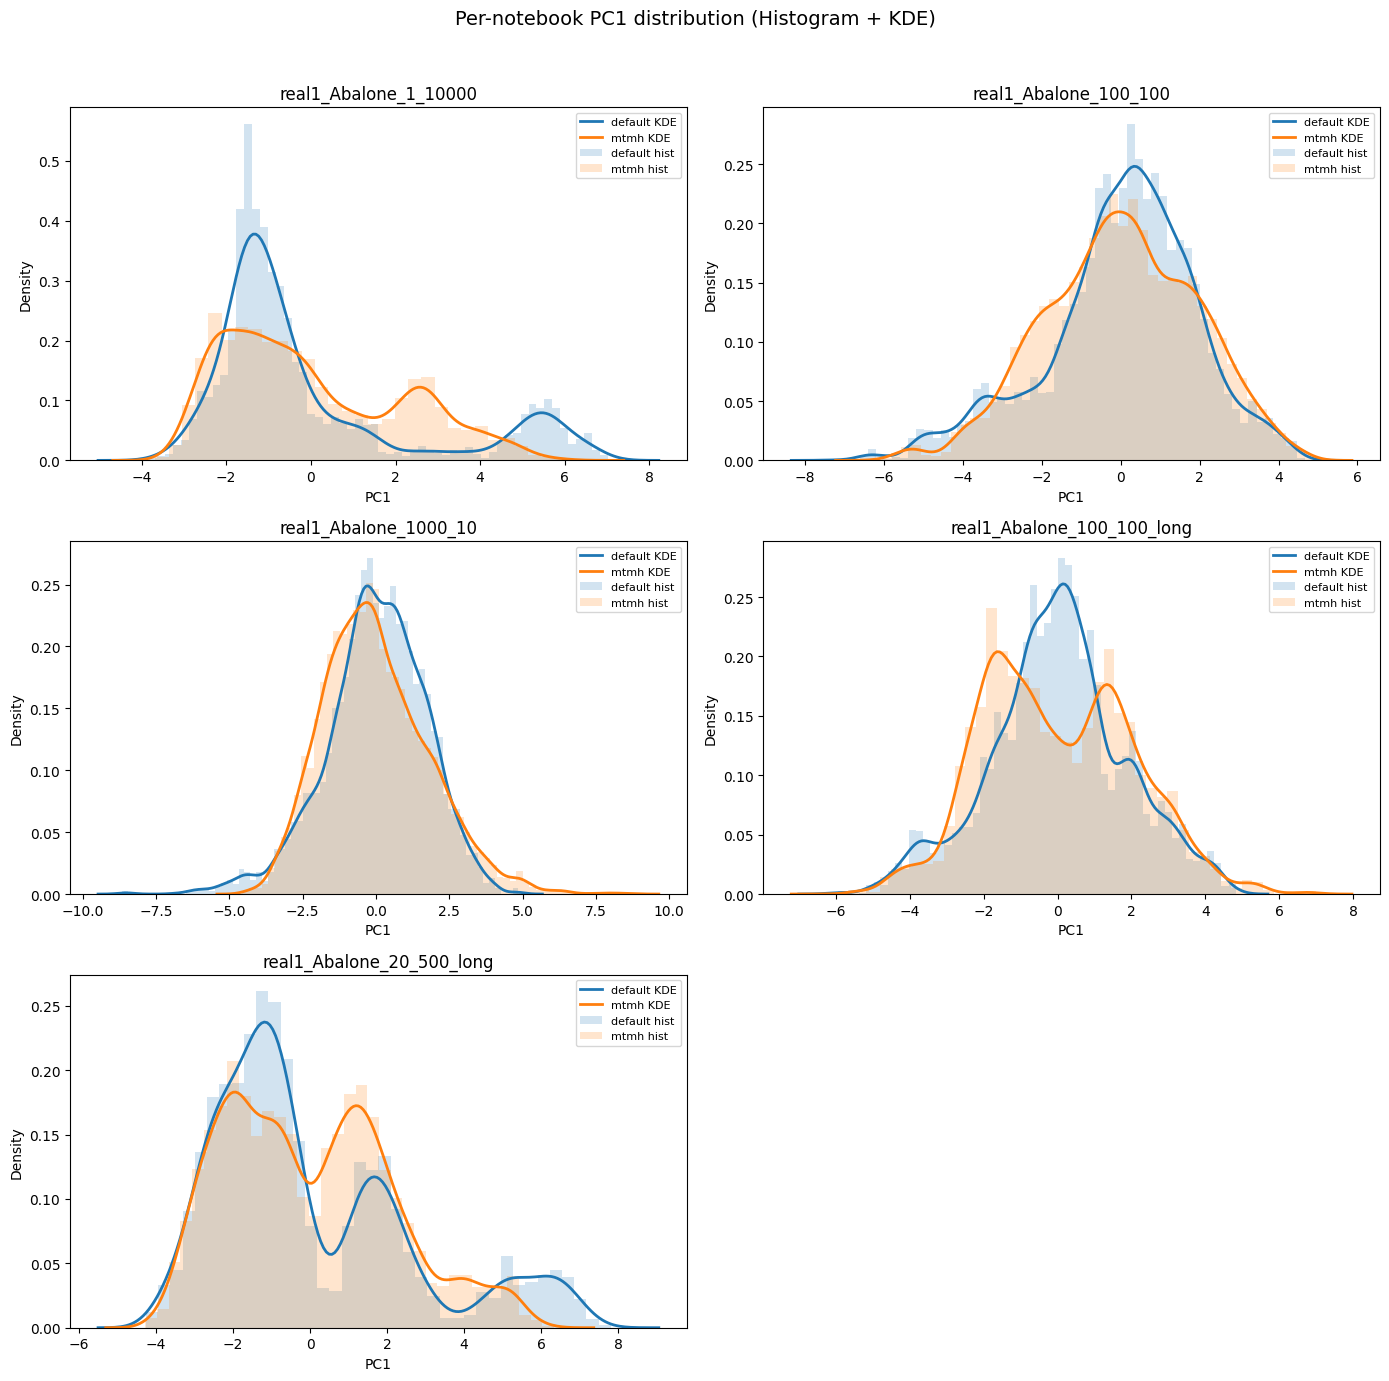

In [7]:
import math
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def preds_to_pc1(preds):
    mat = preds.transpose(0, 2, 1).reshape(-1, preds.shape[1])
    return PCA(n_components=1).fit_transform(mat)[:, 0]

n = len(notebooks)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows))
axes = np.atleast_1d(axes).ravel()

for i, name in enumerate(notebooks):
    npz_path = STORE_DIR / f"{name}.npz"
    default_payload = load_method_payload(npz_path, "default")
    mtmh_payload = load_method_payload(npz_path, "mtmh")

    pc1_default = preds_to_pc1(default_payload["preds"])
    pc1_mtmh = preds_to_pc1(mtmh_payload["preds"])

    ax = axes[i]
    sns.histplot(
        pc1_default,
        bins="auto",
        stat="density",
        alpha=0.20,
        color="#1f77b4",
        edgecolor=None,
        ax=ax,
        label="default hist",
    )
    sns.kdeplot(pc1_default, color="#1f77b4", linewidth=2, ax=ax, label="default KDE")

    sns.histplot(
        pc1_mtmh,
        bins="auto",
        stat="density",
        alpha=0.20,
        color="#ff7f0e",
        edgecolor=None,
        ax=ax,
        label="mtmh hist",
    )
    sns.kdeplot(pc1_mtmh, color="#ff7f0e", linewidth=2, ax=ax, label="mtmh KDE")

    ax.set_title(name)
    ax.set_xlabel("PC1")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Per-notebook PC1 distribution (Histogram + KDE)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

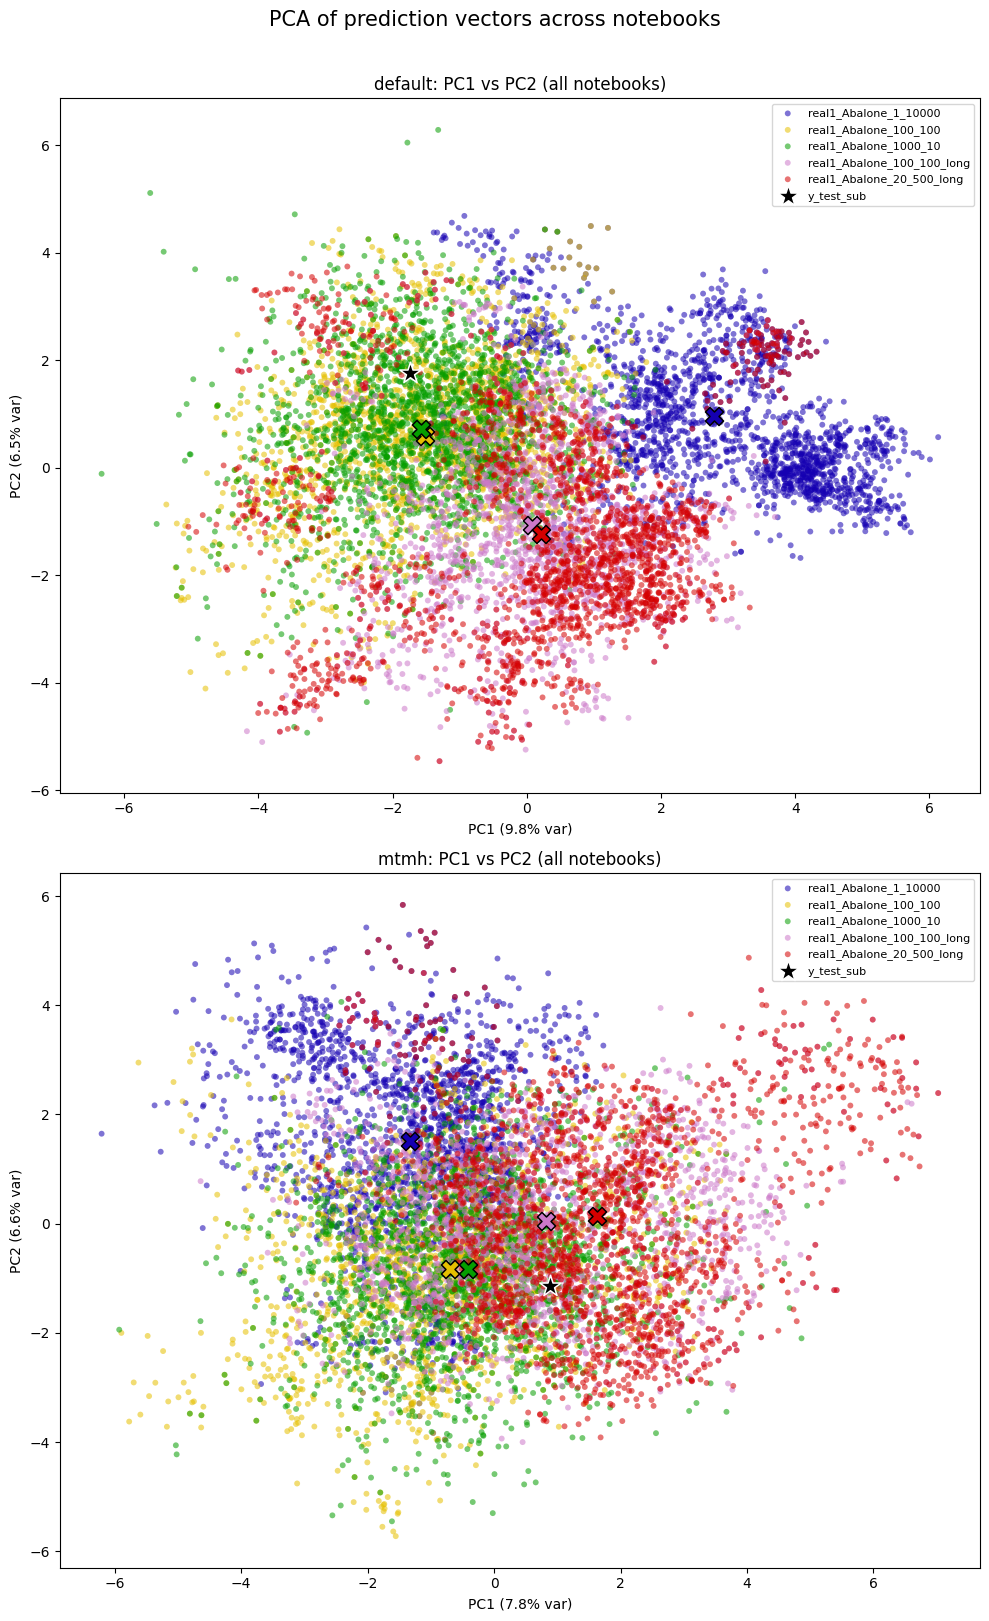

In [8]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def preds_to_matrix(npz_path, method_key):
    payload = load_method_payload(npz_path, method_key)
    preds = payload["preds"]  # (n_chains, n_test, ndpost)
    n_chains, n_test, ndpost = preds.shape
    return preds.transpose(0, 2, 1).reshape(n_chains * ndpost, n_test)

def get_distinct_colors(n):
    base_colors = ["#1500B2", "#E6C000", "#059E00", "#CC79C9", "#D50000"]
    if n <= len(base_colors):
        return base_colors[:n]
    cmap = plt.get_cmap("tab10")
    return [cmap(i % 10) for i in range(n)]

def plot_notebooks_pca_panels(notebook_names, plot_step=5, mark_centroid=True):
    methods = ["default", "mtmh"]
    fig, axes = plt.subplots(2, 1, figsize=(10, 16))
    colors = get_distinct_colors(len(notebook_names))

    for ax, method_key in zip(axes, methods):
        mats = []
        labels = []

        for name in notebook_names:
            npz_path = STORE_DIR / f"{name}.npz"
            mats.append(preds_to_matrix(npz_path, method_key))
            labels.append(name)

        X_all = np.vstack(mats)
        pca = PCA(n_components=2)
        pcs = pca.fit_transform(X_all)

        # Project y_test_sub into the same PCA space for reference.
        n_test_points = X_all.shape[1]
        y_test_sub = get_y_test_subset(y, n_test_points=n_test_points, seed=42)
        y_proj = pca.transform(y_test_sub.reshape(1, -1))[0]

        start = 0
        for i, (mat, label) in enumerate(zip(mats, labels)):
            n_samples = mat.shape[0]
            segment = pcs[start:start + n_samples]
            idx = np.arange(0, n_samples, plot_step)

            ax.scatter(
                segment[idx, 0],
                segment[idx, 1],
                s=18,
                alpha=0.55,
                label=label,
                c=[colors[i]],
                edgecolors="none",
            )

            if mark_centroid:
                centroid = segment.mean(axis=0)
                ax.scatter(
                    centroid[0],
                    centroid[1],
                    s=170,
                    c=[colors[i]],
                    marker="X",
                    edgecolors="black",
                    linewidths=1.1,
                    zorder=5,
                )

            start += n_samples

        ax.scatter(
            y_proj[0],
            y_proj[1],
            s=260,
            c="black",
            marker="*",
            edgecolors="white",
            linewidths=1.1,
            zorder=7,
            label="y_test_sub",
        )

        evr = pca.explained_variance_ratio_
        ax.set_xlabel(f"PC1 ({evr[0] * 100:.1f}% var)")
        ax.set_ylabel(f"PC2 ({evr[1] * 100:.1f}% var)")
        ax.set_title(f"{method_key}: PC1 vs PC2 (all notebooks)")
        ax.legend(loc="best", fontsize=8)

    fig.suptitle("PCA of prediction vectors across notebooks", fontsize=15, y=1.01)
    plt.tight_layout()
    plt.show()

plot_notebooks_pca_panels(notebooks, plot_step=5, mark_centroid=True)